### Unemployment Analysis with Python



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

##### 1. Data Loading


In [3]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Dataset Shape: (768, 7)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Duplicate Rows: 27


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


#### 2. Data Cleaning

Blank rows are removed, column names are cleaned, and the date column is converted to datetime format.

In [4]:
# Remove completely blank rows
df = df.dropna(how="all").copy()

# Clean column names
df.columns = df.columns.str.strip()

# Convert date column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check missing values and duplicates
print("Dataset Shape After Cleaning:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df.head()

Dataset Shape After Cleaning: (740, 7)

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate Rows: 0


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


##### 3. Region-wise Average Unemployment

In [6]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg.round(2)

Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Punjab              12.03
Puducherry          10.22
Kerala              10.12
Tamil Nadu           9.28
Goa                  9.27
Chhattisgarh         9.24
West Bengal          8.12
Telangana            7.74
Maharashtra          7.56
Andhra Pradesh       7.48
Madhya Pradesh       7.41
Sikkim               7.25
Karnataka            6.68
Gujarat              6.66
Uttarakhand          6.58
Assam                6.43
Odisha               5.66
Meghalaya            4.80
Name: Estimated Unemployment Rate (%), dtype: float64

##### Month-wise Unemployment Trend

In [7]:
monthly_avg = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

monthly_avg.round(2)

Date
2019-05-31     8.87
2019-06-30     9.30
2019-07-31     9.03
2019-08-31     9.64
2019-09-30     9.05
2019-10-31     9.90
2019-11-30     9.87
2019-12-31     9.50
2020-01-31     9.95
2020-02-29     9.96
2020-03-31    10.70
2020-04-30    23.64
2020-05-31    24.88
2020-06-30    11.90
Name: Estimated Unemployment Rate (%), dtype: float64

##### 4. Unemployment Trends Over Time

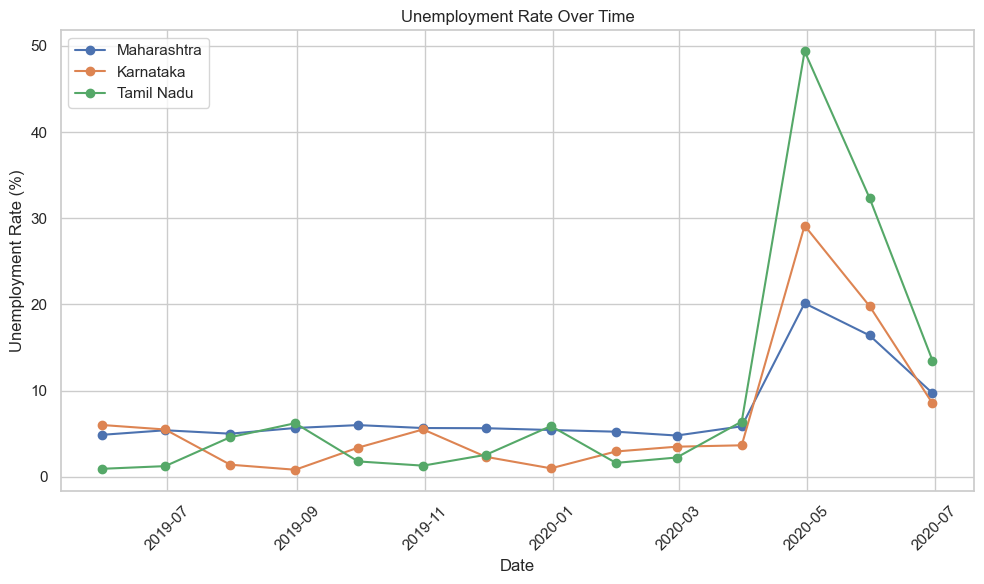

In [8]:
selected_regions = ["Maharashtra", "Karnataka", "Tamil Nadu"]

plt.figure(figsize=(10, 6))

for region in selected_regions:
    region_data = df[df["Region"] == region].groupby("Date")[
        "Estimated Unemployment Rate (%)"
    ].mean()
    
    plt.plot(region_data.index, region_data.values, marker="o", label=region)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Unemployment rates vary over time across the three selected states, with noticeable changes during the COVID-19 period.

##### 5. Top 10 Regions with Highest Average Unemployment

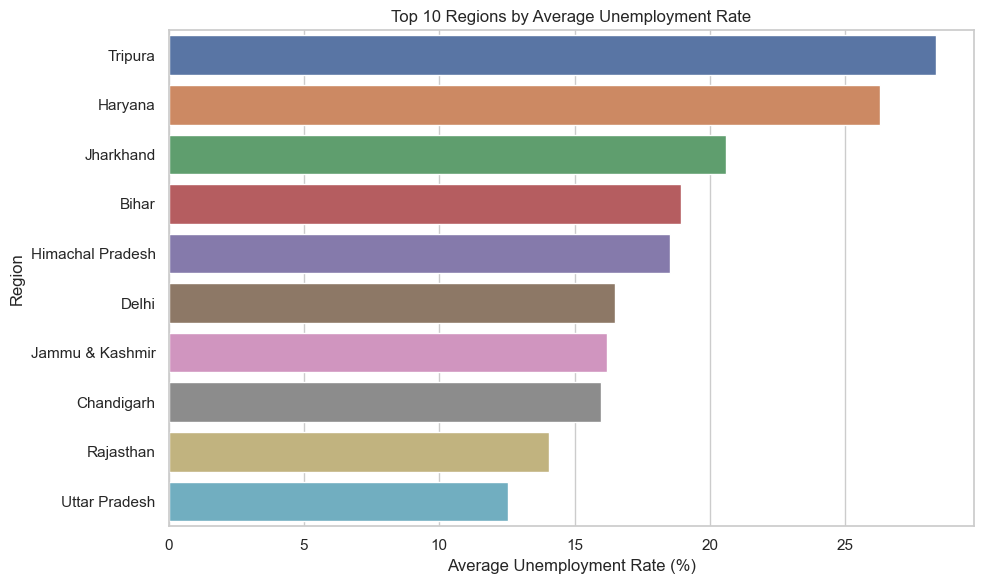

In [9]:
top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

**Observation:** The chart shows the ten regions with the highest average unemployment rates during the period covered by the dataset.

##### 6. Correlation Analysis


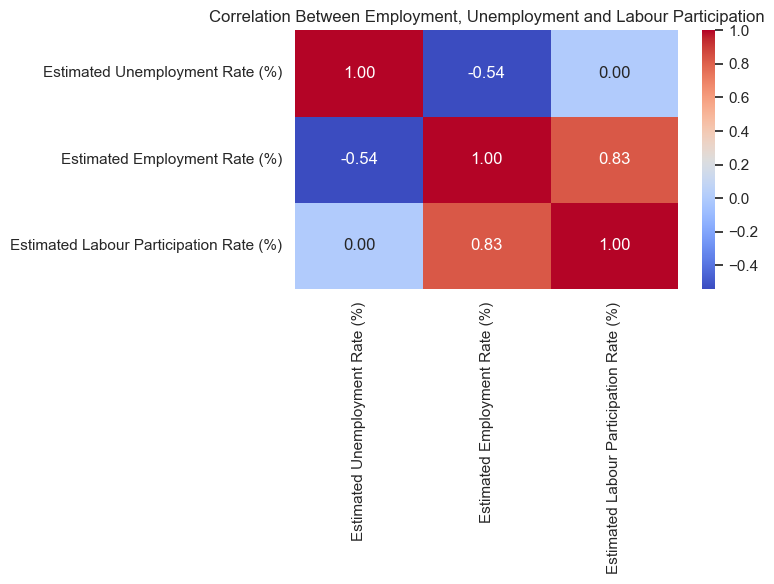

In [10]:
# Calculate derived employment rate
df["Estimated Employment Rate (%)"] = (
    df["Estimated Labour Participation Rate (%)"]
    * (1 - df["Estimated Unemployment Rate (%)"] / 100)
)

correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employment Rate (%)",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment, Unemployment and Labour Participation")
plt.tight_layout()
plt.show()

##### 7. Pre-COVID vs. Post-COVID

Average unemployment rates are compared before and during the COVID-19 period.

In [11]:
pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%)
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


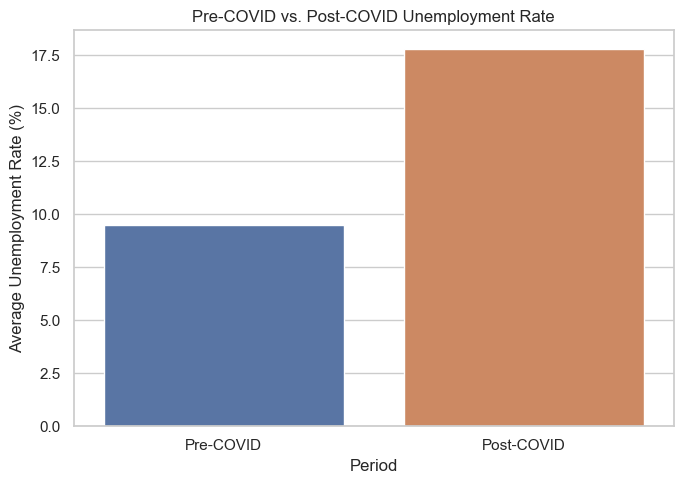

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate (%)"
)

plt.title("Pre-COVID vs. Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

##### 8. Key Observations

- Unemployment rates vary considerably across regions.
- Monthly unemployment rates show changes over the study period.
- The selected states show different unemployment patterns over time.
- The top 10 regions have comparatively higher average unemployment rates.
- The correlation heatmap shows relationships between the selected labour-market indicators.
- The pre-COVID and post-COVID comparison shows a change in unemployment during the COVID-19 period.

#### 9. Conclusion

The analysis provides an overview of regional and temporal unemployment trends in India and highlights changes during the COVID-19 period using exploratory data analysis and visualizations.